In [3]:
# Metagenomic samples

kvmer_sketch_time = [
    "5:00.15",
    "1:45.66",
    "0:55.72",
    "0:24.72",
    
]
kvmer_sketch_memory = [
    "2388612",
    "139604",
    "71296",
    "532016",
]
kvmer_analyze_time = [
    "0:51.44",
    "0:07.98",
    "0:01.68",
    "0:05.02",
]
kvmer_analyze_memory = [
    "3764920",
    "240052",
    "229512",
    "847720",
]

genomescope_time = [
    "15:34.24",
    "19:24.23",
    "5:04.16",
    "1:13.11",


]
genomescope_memory = [
    "31262884",
    "31192936",
    "24418480",
    "12490920"
]

seqtk_time = [
    "5:10.20",
    "3:41.79",
    "1:06.82",
    "0:12.12",
]

seqtk_memory = [
    "205312",
    "52992",
    "2560",
    "104064",
]

minimap_time = [
    "59:51.82",
    "1:19:13",
    "17:58.41",
    "7:21.58",
]

minimap_memory = [
    "4049812",
    "3304116",
    "917040",
    "3800192"
]

label = [
    "Zymo Log, Nanopore GridION",
    "Zymo Gut Microbiome, PacBio Hifi",
    "B. subtilis, Illumina",
    "B. subtilis, PacBio RSII"
]


In [7]:
def wall_time_to_seconds(time_str):
    parts = time_str.split(":")
    parts = [float(part) for part in parts]
    if len(parts) == 3:
        hours, minutes, seconds = parts
    elif len(parts) == 2:
        hours = 0
        minutes, seconds = parts
    else:
        hours = 0
        minutes = 0
        seconds = parts[0]
    total_seconds = hours * 3600 + minutes * 60 + seconds
    return total_seconds

def memory_to_GB(memory_str):
    memory_bytes = int(memory_str)
    memory_gb = memory_bytes / (1024 ** 2)
    return memory_gb



In [8]:
# Sort everything into two DFs: time and memory
import pandas as pd

time_data = {
    "Label": label,
    "KVMer Sketch": [wall_time_to_seconds(t) for t in kvmer_sketch_time],
    "KVMer Analyze": [wall_time_to_seconds(t) for t in kvmer_analyze_time],
    "GenomeScope": [wall_time_to_seconds(t) for t in genomescope_time],
    "Seqtk": [wall_time_to_seconds(t) for t in seqtk_time],
    "Minimap2": [wall_time_to_seconds(t) for t in minimap_time],
}

memory_data = {
    "Label": label,
    "KVMer Sketch": [memory_to_GB(m) for m in kvmer_sketch_memory],
    "KVMer Analyze": [memory_to_GB(m) for m in kvmer_analyze_memory],
    "GenomeScope": [memory_to_GB(m) for m in genomescope_memory],
    "Seqtk": [memory_to_GB(m) for m in seqtk_memory],
    "Minimap2": [memory_to_GB(m) for m in minimap_memory],
}

time_df = pd.DataFrame(time_data)
memory_df = pd.DataFrame(memory_data)

time_df['KVMer'] = time_df['KVMer Sketch'] + time_df['KVMer Analyze']
memory_df['KVMer'] = memory_df[['KVMer Sketch', 'KVMer Analyze']].max(axis=1)

In [9]:
time_df

,Label,KVMer Sketch,KVMer Analyze,GenomeScope,Seqtk,Minimap2,KVMer
0,"Zymo Log, Nanopore GridION",300.15,51.44,934.24,310.20,3591.82,351.59
1,"Zymo Gut Microbiome, PacBio Hifi",105.66,7.98,1164.23,221.79,4753.00,113.64
2,"B. subtilis, Illumina",55.72,1.68,304.16,66.82,1078.41,57.40
3,"B. subtilis, PacBio RSII",24.72,5.02,73.11,12.12,441.58,29.74


In [10]:
memory_df

,Label,KVMer Sketch,KVMer Analyze,GenomeScope,Seqtk,Minimap2,KVMer
0,"Zymo Log, Nanopore GridION",2.277958,3.590508,29.814610,0.195801,3.862202,3.590508
1,"Zymo Gut Microbiome, PacBio Hifi",0.133137,0.228931,29.747902,0.050537,3.151051,0.228931
2,"B. subtilis, Illumina",0.067993,0.218880,23.287277,0.002441,0.874557,0.218880
3,"B. subtilis, PacBio RSII",0.507370,0.808449,11.912270,0.099243,3.624146,0.808449


/tmp/ipykernel_12727/2643169188.py:41: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax2.set_ylim(0, max(memory_values)*3)


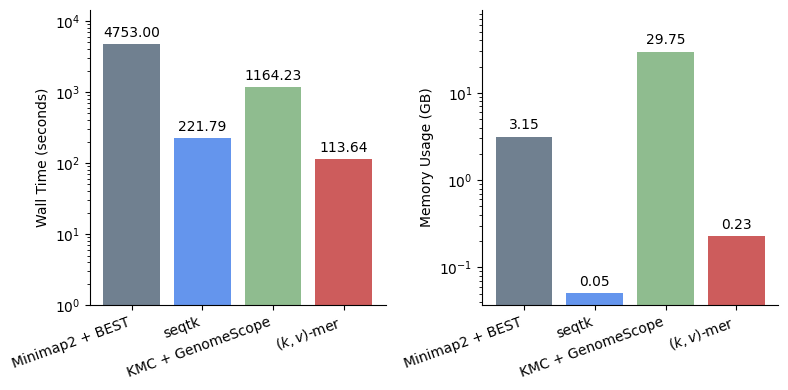

In [33]:
# Plot Zymo Gut Microbiome, PacBio Hifi time and memory usage as two bar plots
import matplotlib.pyplot as plt

sample_index = 1  # Zymo Gut Microbiome, PacBio Hifi
sample_label = label[sample_index]
methods = ["Minimap2", "Seqtk", "GenomeScope", "KVMer"]
methods_labels = ["Minimap2 + BEST", "seqtk", "KMC + GenomeScope",  "$(k,v)$-mer"]
colors = ['slategray', 'cornflowerblue', 'darkseagreen', 'indianred']

time_values = [
    time_df.loc[sample_index, method] for method in methods
]
memory_values = [
    memory_df.loc[sample_index, method] for method in methods
]
x = range(len(methods))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

bars = ax1.bar(x, time_values, color=colors)
ax1.set_xticks(x)
# remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xticklabels(methods_labels, rotation=20, ha='right')
ax1.set_ylabel("Wall Time (seconds)")
ax1.set_yscale("log")
ax1.bar_label(bars, fmt='%.2f', padding=3)
ax1.set_ylim(1, max(time_values)*3)



bars = ax2.bar(x, memory_values, color=colors)
ax2.set_xticks(x)
# remove top and right spines
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xticklabels(methods_labels, rotation=20, ha='right')
ax2.bar_label(bars, fmt='%.2f', padding=3)
ax2.set_ylabel("Memory Usage (GB)")
ax2.set_yscale("log")
ax2.set_ylim(0, max(memory_values)*3)

plt.tight_layout()
plt.savefig("../../figures/time_memory_zymo_pacbio_hifi.pdf")


In [35]:
# Human samples
# Metagenomic samples

kvmer_sketch_time = [
    "16:04.39",
    "16:15.90",
    "18:45.53"


    
]
kvmer_sketch_memory = [
    "574820",
    "1126220",
    "265936"

]
kvmer_analyze_time = [
    "0:39.90",
    "0:39.40",
    "0:37.35",

    
    
]
kvmer_analyze_memory = [
    "907832",
    "1805504",
    "392160"

]

genomescope_time = [
    "1:17:11",
    "1:04:18",
    "1:45:31"
]
genomescope_memory = [
    "31339636",
    "31418448",
    "31379652"

]

seqtk_time = [
    "30:23.54",
    "27:59.65",
    "27:07.24"



]

seqtk_memory = [
    "1628800",
    "3250944",
    "53248",
]

minimap_time = [
    "8:17:47",
    "1:39:02",
    "5:42:13",
]

minimap_memory = [
    "23087968",
    "23087980",
    "23088024"

]

label = [
    "Human, Nanopore R10.4",
    "Human, Nanopore R9.4",
    "Human, PacBio Hifi"
]


In [36]:
# Sort everything into two DFs: time and memory
import pandas as pd

time_data = {
    "Label": label,
    "KVMer Sketch": [wall_time_to_seconds(t) for t in kvmer_sketch_time],
    "KVMer Analyze": [wall_time_to_seconds(t) for t in kvmer_analyze_time],
    "GenomeScope": [wall_time_to_seconds(t) for t in genomescope_time],
    "Seqtk": [wall_time_to_seconds(t) for t in seqtk_time],
    "Minimap2": [wall_time_to_seconds(t) for t in minimap_time],
}

memory_data = {
    "Label": label,
    "KVMer Sketch": [memory_to_GB(m) for m in kvmer_sketch_memory],
    "KVMer Analyze": [memory_to_GB(m) for m in kvmer_analyze_memory],
    "GenomeScope": [memory_to_GB(m) for m in genomescope_memory],
    "Seqtk": [memory_to_GB(m) for m in seqtk_memory],
    "Minimap2": [memory_to_GB(m) for m in minimap_memory],
}

time_df = pd.DataFrame(time_data)
memory_df = pd.DataFrame(memory_data)

time_df['KVMer'] = time_df['KVMer Sketch'] + time_df['KVMer Analyze']
memory_df['KVMer'] = memory_df[['KVMer Sketch', 'KVMer Analyze']].max(axis=1)

In [37]:
time_df

,Label,KVMer Sketch,KVMer Analyze,GenomeScope,Seqtk,Minimap2,KVMer
0,"Human, Nanopore R10.4",964.39,39.90,4631.0,1823.54,29867.0,1004.29
1,"Human, Nanopore R9.4",975.90,39.40,3858.0,1679.65,5942.0,1015.30
2,"Human, PacBio Hifi",1125.53,37.35,6331.0,1627.24,20533.0,1162.88


In [38]:
memory_df

,Label,KVMer Sketch,KVMer Analyze,GenomeScope,Seqtk,Minimap2,KVMer
0,"Human, Nanopore R10.4",0.548191,0.865776,29.887806,1.553345,22.018402,0.865776
1,"Human, Nanopore R9.4",1.074047,1.721863,29.962967,3.100342,22.018414,1.721863
2,"Human, PacBio Hifi",0.253616,0.373993,29.925968,0.050781,22.018456,0.373993
